# Full Fine-Tuning

This notebook studies full fine-tuning of an ImageNet-pretrained ResNet-50 on the Oxford-IIIT Pet classification task.

The previous experiments progressively increased the fine-tuning depth:

```mermaid
flowchart LR
    A["E1: Feature Extraction"] --> B["E2: Layer4 + FC"]
    B --> C["E3: Layer3 + Layer4 + FC"]
    C --> D["E4: Full Fine-Tuning"]
```

E4 removes the remaining freezing constraint.

The experiment is:

$$
\boxed{
\text{E4 — Full Fine-Tuning}
}
$$

The main research question is:

> **Can allowing the entire ImageNet-pretrained ResNet-50 to adapt provide a better target-task representation?**

In E4:

$$
\theta_0=\theta_{\text{ImageNet}}
$$

and:

$$
\boxed{
\text{All model parameters are trainable}
}
$$


## Experiment Configuration

The dataset and training protocol remain unchanged from the previous fine-tuning experiments.

Configuration:

- 37-class Oxford-IIIT Pet classification
- Official `trainval` / `test` split
- Stratified 80/20 train-validation split
- Fixed random seed of 42
- Input resolution of $224\times224$
- Same training and evaluation transforms
- Batch size of 16
- 30 epochs
- AdamW
- Learning rate $10^{-3}$
- Weight decay $10^{-4}$
- Cosine annealing scheduler

The only major experimental change is the set of trainable parameters.

In E4:

$$
\theta_{\text{trainable}}
=
\theta_{\text{all}}
$$

No backbone stage is frozen.

This makes E4 the fully trainable counterpart to the earlier partial fine-tuning experiments.


In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import ResNet50_Weights, resnet50


SEED = 42

DATA_ROOT = Path("../data/raw")

IMAGE_SIZE = 224

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

BATCH_SIZE = 16
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

NUM_EPOCHS = 30

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Seed:", SEED)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Seed: 42
Device: cuda
GPU: NVIDIA GeForce GTX 1650


## Dataset Setup

The same dataset protocol is maintained for E4.

The official test set remains isolated from model selection.

```mermaid
flowchart LR
    A["Oxford-IIIT Pet"] --> B["TrainVal"]
    A --> C["Test"]

    B --> D["Train"]
    B --> E["Validation"]

    D --> F["Optimization"]
    E --> G["Checkpoint Selection"]
    C --> H["Final Evaluation"]
```


In [2]:
dataset_trainval = OxfordIIITPet(
    root=DATA_ROOT,
    split="trainval",
    target_types="category",
    download=False,
)

dataset_test = OxfordIIITPet(
    root=DATA_ROOT,
    split="test",
    target_types="category",
    download=False,
)

indices = np.arange(len(dataset_trainval))
labels = np.array(dataset_trainval._labels)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=labels,
)

print("Train samples:", len(train_indices))
print("Validation samples:", len(val_indices))
print("Test samples:", len(dataset_test))
print("Classes:", len(dataset_trainval.classes))


Train samples: 2944
Validation samples: 736
Test samples: 3669
Classes: 37


## Image Preprocessing

The preprocessing pipeline remains unchanged.

Training uses the baseline augmentation:

```mermaid
flowchart LR
    A["Original Image"] --> B["RandomResizedCrop"]
    B --> C["RandomHorizontalFlip"]
    C --> D["ToTensor"]
    D --> E["ImageNet Normalization"]
    E --> F["224 × 224 Tensor"]
```

Validation and test use deterministic preprocessing:

```text
Resize → CenterCrop → ToTensor → Normalize
```

No stronger augmentation is introduced in E4.

The purpose is to isolate the effect of full parameter adaptation.


In [3]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])


In [4]:
class OxfordPetSubset(Dataset):
    def __init__(
        self,
        base_dataset,
        indices,
        transform=None,
    ):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        real_index = self.indices[index]

        image, label = self.base_dataset[real_index]

        if self.transform is not None:
            image = self.transform(image)

        return image, label


train_dataset = OxfordPetSubset(
    base_dataset=dataset_trainval,
    indices=train_indices,
    transform=train_transform,
)

val_dataset = OxfordPetSubset(
    base_dataset=dataset_trainval,
    indices=val_indices,
    transform=eval_transform,
)

test_dataset = OxfordPetSubset(
    base_dataset=dataset_test,
    indices=np.arange(len(dataset_test)),
    transform=eval_transform,
)


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print(
    "Label range:",
    labels.min().item(),
    labels.max().item(),
)


Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Label range: 1 35


## Load ImageNet-Pretrained ResNet-50

E4 starts from an ImageNet-pretrained ResNet-50.

The pretrained parameters provide the initial representation:

$$
\theta_0=\theta_{\text{ImageNet}}
$$

The network structure is:

```mermaid
flowchart LR
    A["Conv1"] --> B["Layer1"]
    B --> C["Layer2"]
    C --> D["Layer3"]
    D --> E["Layer4"]
    E --> F["Global Average Pool"]
    F --> G["FC"]
```

Unlike E1, E2, and E3, no backbone stage is frozen in E4.


In [6]:
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

print("Loaded ImageNet-pretrained ResNet-50.")


Loaded ImageNet-pretrained ResNet-50.


## Replace the Classification Head

The original ImageNet classifier predicts 1000 classes.

Oxford-IIIT Pet contains 37 target classes.

Therefore:

$$
\mathbb{R}^{2048}
\rightarrow
\mathbb{R}^{37}
$$

The new classifier is randomly initialized.

The pretrained backbone retains its ImageNet parameters before fine-tuning begins.


In [7]:
num_classes = 37

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes,
)


## Enable Full Trainability

All parameters are trainable in E4.

The trainability configuration is:

| Component | Status |
|---|---|
| Conv1 | Trainable |
| Layer1 | Trainable |
| Layer2 | Trainable |
| Layer3 | Trainable |
| Layer4 | Trainable |
| FC | Trainable |

The optimization space is therefore:

$$
\theta_{\text{trainable}}
=
\theta_{\text{all}}
$$

The complete parameter flow is:

```mermaid
flowchart LR
    A["Conv1"]:::trainable --> B["Layer1"]:::trainable
    B --> C["Layer2"]:::trainable
    C --> D["Layer3"]:::trainable
    D --> E["Layer4"]:::trainable
    E --> F["FC"]:::trainable

    classDef trainable stroke-width: 3;
```


In [8]:
# Explicitly enable gradients for every parameter.
for parameter in model.parameters():
    parameter.requires_grad = True

model = model.to(device)


## Verify Trainable Parameters

Before training, we verify that every component is trainable.

For E4:

$$
\text{Trainable Parameters}
=
\text{Total Parameters}
$$

Therefore:

$$
\frac{
N_{\text{trainable}}
}{
N_{\text{total}}
}
=
1
$$

This check ensures that E4 is genuinely full fine-tuning rather than a partial fine-tuning configuration.


In [9]:
def count_parameters(module):
    total = sum(
        parameter.numel()
        for parameter in module.parameters()
    )

    trainable = sum(
        parameter.numel()
        for parameter in module.parameters()
        if parameter.requires_grad
    )

    return total, trainable


components = {
    "conv1": model.conv1,
    "layer1": model.layer1,
    "layer2": model.layer2,
    "layer3": model.layer3,
    "layer4": model.layer4,
    "fc": model.fc,
}

rows = []

for name, module in components.items():
    total, trainable = count_parameters(module)

    rows.append({
        "component": name,
        "total_params": total,
        "trainable_params": trainable,
        "trainable": trainable > 0,
    })

parameter_status = pd.DataFrame(rows)

parameter_status


,component,total_params,trainable_params,trainable
0,conv1,9408,9408,True
1,layer1,215808,215808,True
2,layer2,1219584,1219584,True
3,layer3,7098368,7098368,True
4,layer4,14964736,14964736,True
5,fc,75813,75813,True


In [10]:
total_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(
    f"Trainable ratio:      "
    f"{trainable_params / total_params:.2%}"
)


Total parameters:     23,583,845
Trainable parameters: 23,583,845
Trainable ratio:      100.00%


## What Full Fine-Tuning Means

In E4, the pretrained model provides the initial parameter state:

$$
\theta_0=\theta_{\text{ImageNet}}
$$

The entire parameter vector is then optimized:

$$
\theta^*
=
\arg\min_{\theta}
\frac{1}{N}
\sum_{i=1}^{N}
\mathcal{L}
\left(
f_{\theta}(x_i),y_i
\right)
$$

Unlike feature extraction, the pretrained representation is no longer treated as fixed.

Every layer can adapt to the target task.

The conceptual flow is:

```mermaid
flowchart LR
    A["ImageNet Representation"] --> B["Target Task"]
    B --> C["Adapt Early Features"]
    C --> D["Adapt Mid-Level Features"]
    D --> E["Adapt High-Level Features"]
    E --> F["Adapt Classifier"]
```

This gives the model the maximum flexibility within the current architecture.


## Training Objective

For an input image $x$:

$$
z=f_\theta(x)
$$

where:

$$
z\in\mathbb{R}^{37}
$$

The Cross-Entropy loss is:

$$
\mathcal{L}
=
-\log p_y
$$

The optimization update is applied to every trainable parameter:

$$
\theta_{t+1}
=
\theta_t
-
\eta
\nabla_\theta
\mathcal{L}_t
$$

Because all layers are trainable, gradients can influence the entire representation hierarchy.


## Optimizer

E4 keeps the same baseline optimization recipe used in E1–E3:

$$
\eta=10^{-3}
$$

$$
\lambda=10^{-4}
$$

We use AdamW with cosine learning-rate decay.

This is intentionally a baseline configuration.

We do not introduce:

- discriminative learning rates;
- stronger regularization;
- additional augmentation;
- optimizer search.

Those belong to later experimental phases.


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
)


## Training Loop

The forward and backward passes now update the complete network.

```mermaid
flowchart LR
    A["Input"] --> B["Full ResNet-50"]
    B --> C["Logits"]
    C --> D["Loss"]

    D --> E["Backward"]
    E --> F["Update Conv1"]
    E --> G["Update Layer1"]
    E --> H["Update Layer2"]
    E --> I["Update Layer3"]
    E --> J["Update Layer4"]
    E --> K["Update FC"]
```

The main difference from E3 is that there are no frozen backbone parameters.


In [12]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(
            device,
            non_blocking=True,
        )

        labels = labels.to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(
            logits,
            labels,
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = logits.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / total,
        correct / total,
    )


In [13]:
def evaluate(
    model,
    loader,
    criterion,
    device,
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(
                device,
                non_blocking=True,
            )

            labels = labels.to(
                device,
                non_blocking=True,
            )

            logits = model(images)

            loss = criterion(
                logits,
                labels,
            )

            running_loss += (
                loss.item()
                * images.size(0)
            )

            predictions = logits.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return (
        running_loss / total,
        correct / total,
    )


## Training History

We record:

- training loss
- training accuracy
- validation loss
- validation accuracy
- learning rate

These metrics will allow us to inspect how full fine-tuning behaves during optimization.


In [14]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": [],
}


## Best Checkpoint

The best E4 checkpoint is selected using validation accuracy.

```mermaid
flowchart LR
    A["Epoch"] --> B["Validation Accuracy"]
    B --> C{"Improved?"}
    C -->|Yes| D["Save E4 Checkpoint"]
    C -->|No| E["Continue Training"]
```

The official test set is not used for checkpoint selection.


In [15]:
checkpoint_dir = Path(
    "../experiments/checkpoints"
)

checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True,
)

best_val_accuracy = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    val_loss, val_accuracy = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["learning_rate"].append(current_lr)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy

        torch.save(
            {
                "experiment": "E4",
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": val_accuracy,
            },
            checkpoint_dir
            / "resnet50_full_finetuning_best.pt",
        )

    scheduler.step()

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2%} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2%} | "
        f"LR: {current_lr:.2e}"
    )


Epoch [01/30] | Train Loss: 2.5194 | Train Acc: 30.06% | Val Loss: 1.8290 | Val Acc: 45.38% | LR: 1.00e-03
Epoch [02/30] | Train Loss: 1.6843 | Train Acc: 50.88% | Val Loss: 1.4839 | Val Acc: 58.15% | LR: 9.97e-04
Epoch [03/30] | Train Loss: 1.4418 | Train Acc: 57.64% | Val Loss: 1.2043 | Val Acc: 66.17% | LR: 9.89e-04
Epoch [04/30] | Train Loss: 1.2677 | Train Acc: 62.40% | Val Loss: 1.1145 | Val Acc: 68.48% | LR: 9.76e-04
Epoch [05/30] | Train Loss: 1.1574 | Train Acc: 64.23% | Val Loss: 1.0498 | Val Acc: 67.93% | LR: 9.57e-04
Epoch [06/30] | Train Loss: 1.0594 | Train Acc: 67.43% | Val Loss: 0.7340 | Val Acc: 76.90% | LR: 9.33e-04
Epoch [07/30] | Train Loss: 0.9739 | Train Acc: 70.89% | Val Loss: 0.7990 | Val Acc: 76.22% | LR: 9.05e-04
Epoch [08/30] | Train Loss: 0.9005 | Train Acc: 72.72% | Val Loss: 0.6752 | Val Acc: 78.94% | LR: 8.72e-04
Epoch [09/30] | Train Loss: 0.8000 | Train Acc: 75.82% | Val Loss: 0.6628 | Val Acc: 80.57% | LR: 8.35e-04
Epoch [10/30] | Train Loss: 0.7679 | 

## Load the Best E4 Checkpoint

After training, restore the checkpoint with the highest validation accuracy.

This checkpoint will be used for the final test evaluation.


In [16]:
checkpoint = torch.load(
    checkpoint_dir
    / "resnet50_full_finetuning_best.pt",
    map_location=device,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_epoch = checkpoint["epoch"]

print("Best epoch:", best_epoch)

print(
    "Best validation accuracy:",
    f"{checkpoint['val_accuracy']:.2%}",
)


Best epoch: 28
Best validation accuracy: 91.30%


## Learning Curves

The training curves are used to inspect the behavior of the fully fine-tuned model.

We are interested in:

- convergence speed;
- training performance;
- validation performance;
- the train-validation gap;
- potential overfitting;
- whether validation performance continues improving as the learning rate decays.


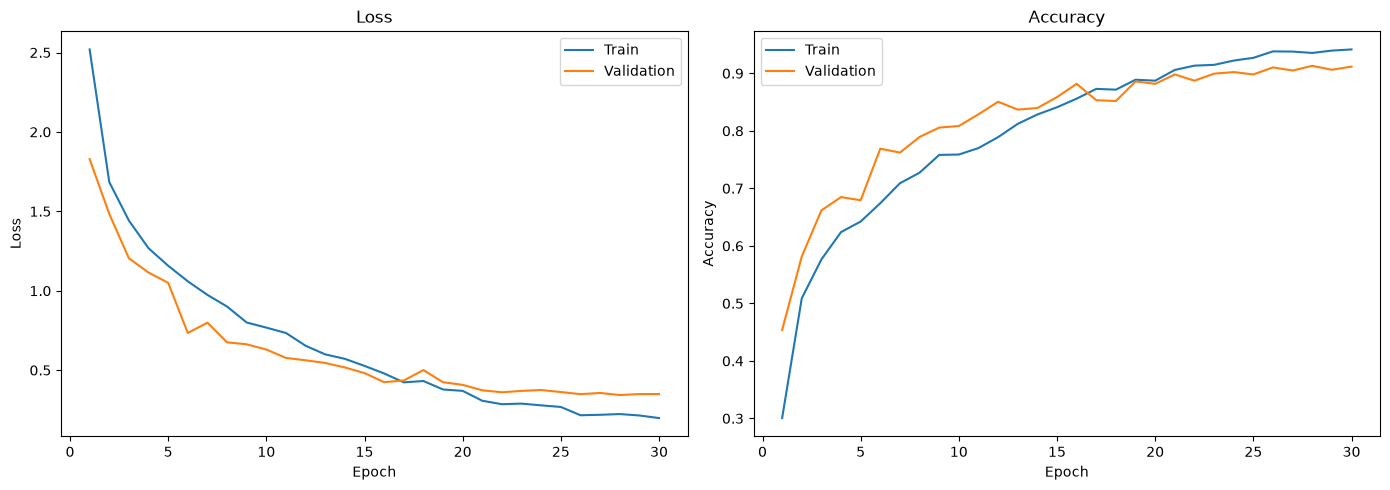

In [17]:
epochs = range(
    1,
    NUM_EPOCHS + 1,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

axes[0].plot(
    epochs,
    history["train_loss"],
    label="Train",
)

axes[0].plot(
    epochs,
    history["val_loss"],
    label="Validation",
)

axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    epochs,
    history["train_accuracy"],
    label="Train",
)

axes[1].plot(
    epochs,
    history["val_accuracy"],
    label="Validation",
)

axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


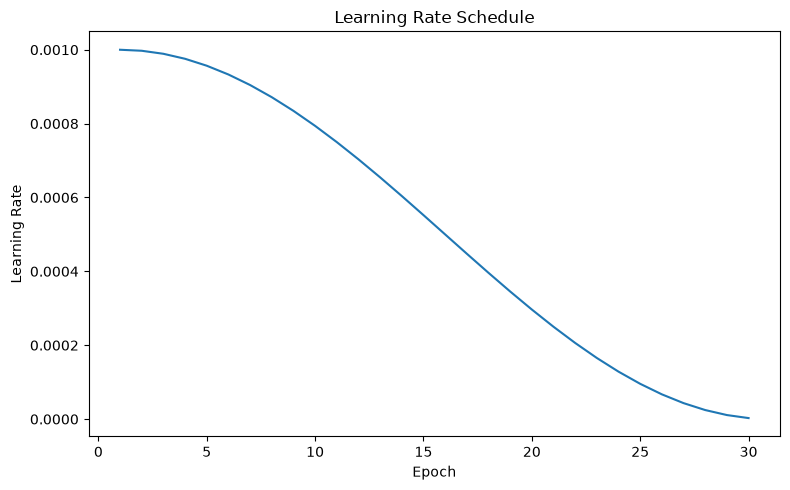

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["learning_rate"],
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")

plt.tight_layout()
plt.show()


## Validation Evaluation

The validation set is used to determine the best E4 checkpoint.

We report:

- validation loss;
- validation accuracy;
- best epoch.

The test set is not involved in this selection process.


In [19]:
best_val_loss, best_val_accuracy = evaluate(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device,
)

print(
    f"Best Validation Loss: "
    f"{best_val_loss:.4f}"
)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.2%}"
)

print("Best Epoch:", best_epoch)


Best Validation Loss: 0.3435
Best Validation Accuracy: 91.30%
Best Epoch: 28


## Final Evaluation on the Test Set

After selecting the best E4 checkpoint using validation performance, we evaluate it once on the official test set.

The test set is not used for:

- checkpoint selection;
- hyperparameter tuning;
- architecture selection.


In [20]:
test_loss, test_accuracy = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
)

print(
    f"E4 Test Loss: "
    f"{test_loss:.4f}"
)

print(
    f"E4 Test Accuracy: "
    f"{test_accuracy:.2%}"
)


E4 Test Loss: 0.4868
E4 Test Accuracy: 87.22%


## E4 Baseline Result

The E4 experiment records:

- trainable parameter count;
- training configuration;
- best epoch;
- validation performance;
- test performance;
- fine-tuning strategy.


In [21]:
e4_result = pd.DataFrame([{
    "experiment": "E4",
    "model": "ResNet-50",
    "initialization": "ImageNet",
    "trainable_params": trainable_params,
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "best_epoch": best_epoch,
    "best_val_accuracy": best_val_accuracy,
    "best_val_loss": best_val_loss,
    "test_accuracy": test_accuracy,
    "test_loss": test_loss,
    "strategy": "Full Fine-Tuning",
}])

e4_result


,experiment,model,initialization,trainable_params,epochs,batch_size,learning_rate,weight_decay,best_epoch,best_val_accuracy,best_val_loss,test_accuracy,test_loss,strategy
0,E4,ResNet-50,ImageNet,23583845,30,16,0.001,0.0001,28,0.913043,0.343463,0.872172,0.486822,Full Fine-Tuning


## Save E4 Experiment Result

The experiment result is saved immediately after final test evaluation.

The central result file is updated while avoiding duplicate E4 entries if the notebook is rerun.


In [22]:
results_dir = Path(
    "../experiments/results"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True,
)

e4_result.to_csv(
    results_dir
    / "e4_full_finetuning.csv",
    index=False,
)

results_path = (
    results_dir
    / "experiment_results.csv"
)

if results_path.exists():
    existing_results = pd.read_csv(
        results_path
    )

    existing_results = existing_results[
        existing_results["experiment"] != "E4"
    ]

    experiment_results = pd.concat(
        [
            existing_results,
            e4_result,
        ],
        ignore_index=True,
    )
else:
    experiment_results = e4_result.copy()

experiment_results.to_csv(
    results_path,
    index=False,
)

experiment_results


,experiment,model,initialization,trainable_params,epochs,batch_size,learning_rate,weight_decay,best_epoch,best_val_accuracy,best_val_loss,test_accuracy,test_loss,strategy
0,E0,ResNet-50,Random,23583845,30,16,0.001,0.0001,30,0.338315,2.317437,0.288907,2.500295,NaN
1,E1,ResNet-50,ImageNet,75813,30,16,0.001,0.0001,16,0.937500,0.226684,0.911420,0.292235,Feature Extraction
2,E2,ResNet-50,ImageNet,15040549,30,16,0.001,0.0001,21,0.947011,0.214195,0.911965,0.366784,Layer4 + FC Fine-Tuning
3,E3,ResNet-50,ImageNet,22138917,30,16,0.001,0.0001,26,0.929348,0.265825,0.879531,0.468232,Layer3 + Layer4 Fine-Tuning
4,E4,ResNet-50,ImageNet,23583845,30,16,0.001,0.0001,28,0.913043,0.343463,0.872172,0.486822,Full Fine-Tuning


# Conclusions

E4 completes the progressive fine-tuning-depth study.

The model starts from ImageNet-pretrained parameters:

$$
\theta_0=\theta_{\text{ImageNet}}
$$

and all parameters are trainable:

$$
\boxed{
\theta_{\text{trainable}}
=
\theta_{\text{all}}
}
$$

The experiment therefore represents:

> **Full Fine-Tuning of an ImageNet-pretrained ResNet-50**

This concludes the controlled sequence:

```mermaid
flowchart LR
    A["E1: Feature Extraction"] --> B["E2: Layer4 Fine-Tuning"]
    B --> C["E3: Layer3-4 Fine-Tuning"]
    C --> D["E4: Full Fine-Tuning"]
```

The next stage moves from fine-tuning depth to training strategy:

> **E5 — Data Augmentation Experiments**
